<a href="https://colab.research.google.com/github/AbdelrahmanSallam04/Drowsy_Driver/blob/main/Drowsy_Driver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define your base path
base_dir = '/content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files'

# Function to count files in subfolders
def count_files(directory):
    for root, dirs, files in os.walk(directory):
        if not dirs: # Only look at the final subdirectories
            print(f"Found {len(files)} files in: {root}")

count_files(base_dir)

Found 456 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/test/active
Found 453 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/test/fatigue
Found 5862 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/train/active
Found 3192 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/train/fatigue
Found 912 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/val/active
Found 912 files in: /content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files/val/fatigue


In [ ]:
import tensorflow as tf

# Configuration
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Standard for models like MobileNetV2 or ResNet
BASE_PATH = '/content/drive/MyDrive/DrowsyDriver_Dataset/dataset_files'

# Create Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, 'train'),
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Create Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, 'val'),
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Create Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, 'test'),
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Show the class names to verify
class_names = train_ds.class_names
print(f"Detected classes: {class_names}")

Found 9054 files belonging to 2 classes.
Found 1824 files belonging to 2 classes.
Found 909 files belonging to 2 classes.
Detected classes: ['active', 'fatigue']


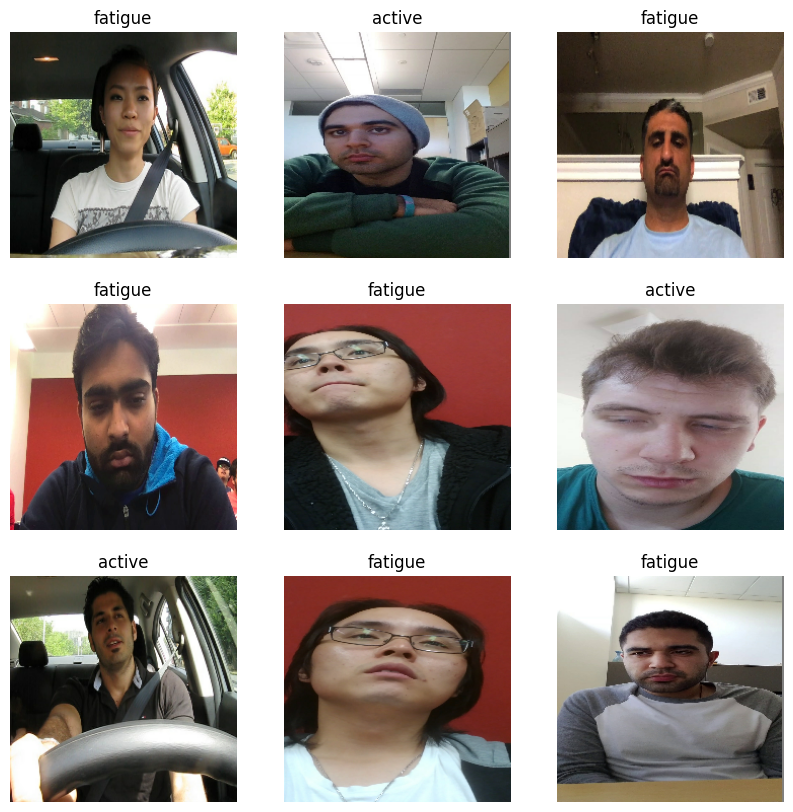

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Replace your manual OpenCV function with this Layer
data_augmentation = tf.keras.Sequential([
    # Flip images to simulate different driver positions (LHD vs RHD)
    layers.RandomFlip("horizontal"),

    # Slight rotation (0.02 = ~7°) to account for head tilting
    layers.RandomRotation(0.02),

    # Adjust brightness (±30%) to simulate different times of day/night driving
    layers.RandomBrightness(0.3),

    # Adjust contrast to help the model find edges in low-light conditions
    layers.RandomContrast(0.3),

    # Shifting the image slightly to make the model robust to camera mounting positions
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
])

# --- APPLYING TO DATASET ---
# We use .map to inject the augmentation logic into the data pipeline.
# 'training=True' ensures augmentation only happens during training, not evaluation.
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# --- OPTIMIZATION ---
# AUTOTUNE allows the CPU to prepare the next batch of images (augmenting/loading)
# while the GPU is training on the current batch.
# This eliminates "bottlenecks" where the GPU is waiting for data.
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

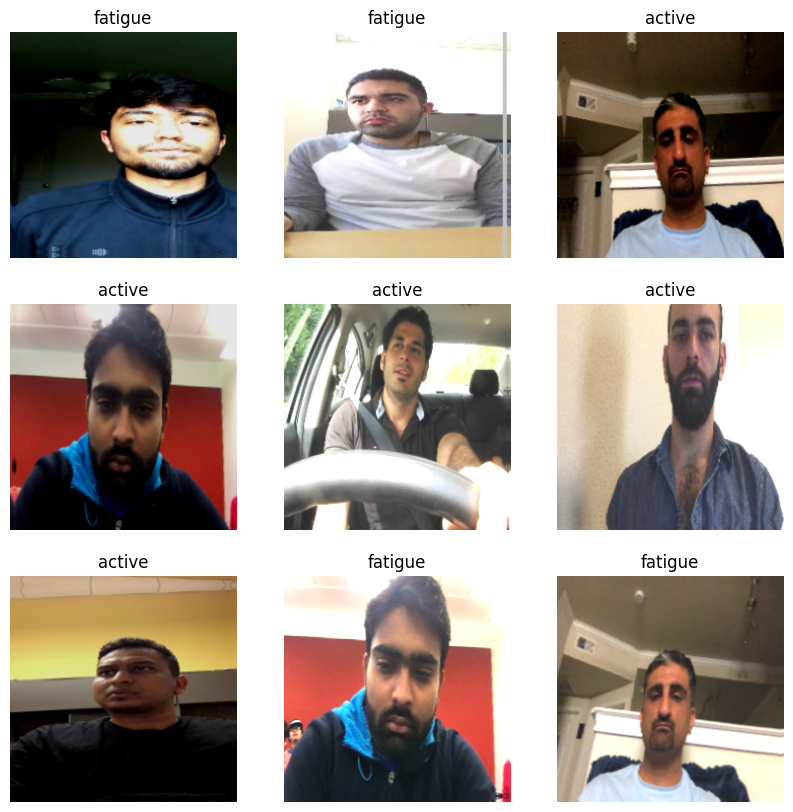

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Define the Input Shape (must match your dataset image size)
IMG_SHAPE = (224, 224, 3)

# 2. Load the Pre-trained Base (MobileNetV2)
# include_top=False means we throw away the original 1000-class classifier
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

# 3. Build the "Head" (The part that decides Active vs. Fatigue)
model = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1, input_shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(), # Reduces 7x7 map to a single vector
    layers.Dropout(0.2),             # Prevents overfitting (shuts off 20% of neurons randomly)
    layers.Dense(1, activation='sigmoid') # Sigmoid for Binary Classification (0 to 1)
])

# 4. Unfreeze the top layers
base_model.trainable = True
fine_tune_at = 120 # Freeze everything except the last 34 layers

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 5. Compile
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,626,177 (6.20 MB)

 Non-trainable params: 633,088 (2.42 MB)

In [ ]:
# Calculate weights based on your training counts: 5862 (Active) vs 3192 (Fatigue)
total = 5862 + 3192
weight_for_0 = (1 / 5862) * (total / 2.0)
weight_for_1 = (1 / 3192) * (total / 2.0)

class_weights = {0: weight_for_0, 1: weight_for_1}

print(f"Weight for Class 0 (Active): {weight_for_0:.2f}")
print(f"Weight for Class 1 (Fatigue): {weight_for_1:.2f}")
# You should see Class 1 weighted at ~1.42 and Class 0 at ~0.77

Weight for Class 0 (Active): 0.77
Weight for Class 1 (Fatigue): 1.42


In [ ]:
my_callbacks = [
    # 1. Save the best model weights
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_accuracy',
        save_best_only=True
    ),

    # 2. Stop if we stop improving for 5 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    # 3. Lower learning rate if progress stalls
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3
    )
]

In [ ]:
# This is where the magic happens
history = model.fit(
    train_ds,              # Your dataset (which ALREADY has the augmentation map attached)
    validation_data=val_ds, # The model uses this to check its progress (no augmentation here!)
    epochs=20,              # How many times to repeat the whole process
    class_weight=class_weights,
    callbacks=my_callbacks
)

Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.6665 - loss: 0.5612

283/283 ━━━━━━━━━━━━━━━━━━━━ 211s 688ms/step - accuracy: 0.6678 - loss: 0.5514 - val_accuracy: 0.7599 - val_loss: 0.4592 - learning_rate: 1.0000e-05
Epoch 2/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.6660 - loss: 0.5470

283/283 ━━━━━━━━━━━━━━━━━━━━ 194s 685ms/step - accuracy: 0.6637 - loss: 0.5450 - val_accuracy: 0.8141 - val_loss: 0.4100 - learning_rate: 1.0000e-05
Epoch 3/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.6663 - loss: 0.5396

283/283 ━━━━━━━━━━━━━━━━━━━━ 199s 675ms/step - accuracy: 0.6681 - loss: 0.5391 - val_accuracy: 0.8405 - val_loss: 0.3951 - learning_rate: 1.0000e-05
Epoch 4/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.6603 - loss: 0.5501

283/283 ━━━━━━━━━━━━━━━━━━━━ 187s 660ms/step - accuracy: 0.6662 - loss: 0.5443 - val_accuracy: 0.8564 - val_loss: 0.3830 - learning_rate: 1.0000e-05
Epoch 5/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.6640 - loss: 0.5429

...

283/283 ━━━━━━━━━━━━━━━━━━━━ 188s 664ms/step - accuracy: 0.6682 - loss: 0.5379 - val_accuracy: 0.8909 - val_loss: 0.3549 - learning_rate: 1.0000e-05
Epoch 9/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 203s 668ms/step - accuracy: 0.6649 - loss: 0.5379 - val_accuracy: 0.8876 - val_loss: 0.3566 - learning_rate: 1.0000e-05
Epoch 10/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.6663 - loss: 0.5408

283/283 ━━━━━━━━━━━━━━━━━━━━ 189s 668ms/step - accuracy: 0.6692 - loss: 0.5375 - val_accuracy: 0.8947 - val_loss: 0.3440 - learning_rate: 1.0000e-05
Epoch 11/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.6638 - loss: 0.5392

283/283 ━━━━━━━━━━━━━━━━━━━━ 196s 649ms/step - accuracy: 0.6685 - loss: 0.5339 - val_accuracy: 0.8997 - val_loss: 0.3418 - learning_rate: 1.0000e-05
Epoch 12/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.6691 - loss: 0.5396

283/283 ━━━━━━━━━━━━━━━━━━━━ 188s 662ms/step - accuracy: 0.6719 - loss: 0.5371 - val_accuracy: 0.9035 - val_loss: 0.3406 - learning_rate: 1.0000e-05
Epoch 13/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 188s 662ms/step - accuracy: 0.6758 - loss: 0.5323 - val_accuracy: 0.9024 - val_loss: 0.3462 - learning_rate: 1.0000e-05
Epoch 14/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 200s 654ms/step - accuracy: 0.6706 - loss: 0.5337 - val_accuracy: 0.8975 - val_loss: 0.3386 - learning_rate: 1.0000e-05
Epoch 15/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 204s 660ms/step - accuracy: 0.6733 - loss: 0.5273 - val_accuracy: 0.8997 - val_loss: 0.3339 - learning_rate: 1.0000e-05
Epoch 16/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.6646 - loss: 0.5350

283/283 ━━━━━━━━━━━━━━━━━━━━ 189s 667ms/step - accuracy: 0.6735 - loss: 0.5290 - val_accuracy: 0.9123 - val_loss: 0.3253 - learning_rate: 1.0000e-05
Epoch 17/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 186s 653ms/step - accuracy: 0.6704 - loss: 0.5305 - val_accuracy: 0.9090 - val_loss: 0.3327 - learning_rate: 1.0000e-05
Epoch 18/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 185s 652ms/step - accuracy: 0.6692 - loss: 0.5313 - val_accuracy: 0.9084 - val_loss: 0.3365 - learning_rate: 1.0000e-05
Epoch 19/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 188s 663ms/step - accuracy: 0.6705 - loss: 0.5298 - val_accuracy: 0.9073 - val_loss: 0.3336 - learning_rate: 1.0000e-05
Epoch 20/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 185s 650ms/step - accuracy: 0.6765 - loss: 0.5253 - val_accuracy: 0.9079 - val_loss: 0.3333 - learning_rate: 2.0000e-06


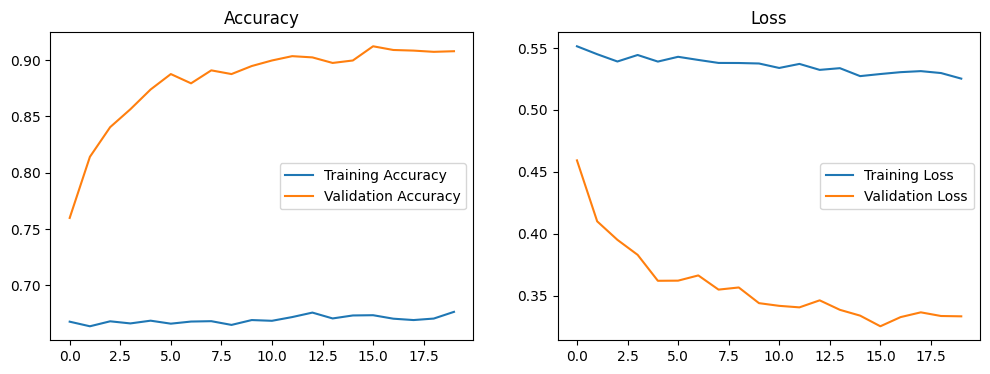

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1] * 100:.2f}%")

29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 304ms/step - accuracy: 0.9098 - loss: 0.3118
Test Loss: 0.3117910325527191
Test Accuracy: 90.98%


In [ ]:
# Save in the native Keras format
model.save('/content/drive/MyDrive/DrowsyDriver_Dataset/drowsy_model_v1.keras')
print("Model Saved to Drive!")

Model Saved to Drive!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

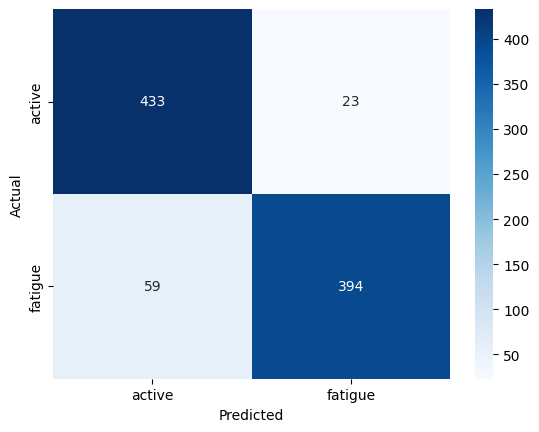

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get the true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

# 2. Plot the matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()